In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "oasis_longitudinal.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jboysen/mri-and-alzheimers",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/var/folders/ls/vwzpb4gs5p11s0862ytdycch0000gn/T/ipykernel_15951/238782329.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 27.6k/27.6k [00:00<00:00, 1.68MB/s]

First 5 records:   Subject ID         MRI ID        Group  Visit  MR Delay M/F Hand  Age  EDUC  \
0  OAS2_0001  OAS2_0001_MR1  Nondemented      1         0   M    R   87    14   
1  OAS2_0001  OAS2_0001_MR2  Nondemented      2       457   M    R   88    14   
2  OAS2_0002  OAS2_0002_MR1     Demented      1         0   M    R   75    12   
3  OAS2_0002  OAS2_0002_MR2     Demented      2       560   M    R   76    12   
4  OAS2_0002  OAS2_0002_MR3     Demented      3      1895   M    R   80    12   

   SES  MMSE  CDR  eTIV   nWBV    ASF  
0  2.0  27.0  0.0  1987  0.696  0.883  
1  2.0  30.0  0.0  2004  0.681  0.876  
2  NaN  23.0  0.5  1678  0.736  1.046  
3  NaN  28.0  0.5  1738  0.713  1.010  
4  NaN  22.0  0.5  1698  0.701  1.034  


In [22]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler

df = df.copy()


df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,2.0,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,2.0,22.0,0.5,1698,0.701,1.034


In [23]:
df["MMSE"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 373 entries, 0 to 372
Series name: MMSE
Non-Null Count  Dtype  
--------------  -----  
373 non-null    float64
dtypes: float64(1)
memory usage: 3.0 KB


In [27]:
features_pca = ["MR Delay", "Age", "EDUC", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF"]

df["SES"] = df["SES"].fillna(df["SES"].median())
df["MMSE"] = df["MMSE"].fillna(df["MMSE"].median())

df_visit_1 = df[df["Visit"] == 1].copy()


scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_visit_1[features_pca])

scaled_data.shape

(150, 9)

# PCA 
### Visit 1 

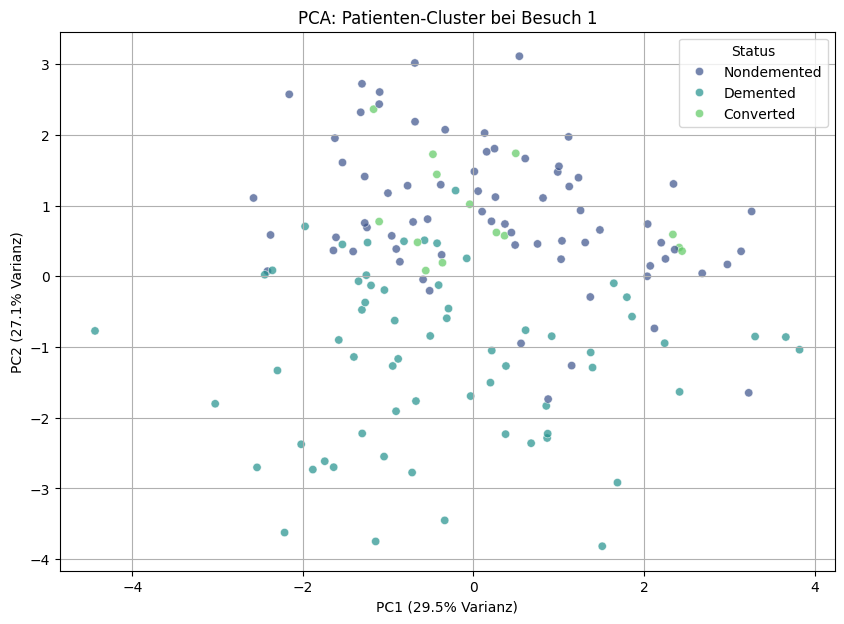

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca =PCA(n_components=2)
pca_res = pca.fit_transform(scaled_data)


df_pca = pd.DataFrame(data = pca_res, columns= ["PC1", "PC2"])
df_pca["Status"] = df_visit_1["Group"].values

# visualise

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Status', data=df_pca, palette='viridis', alpha=0.7)
plt.title('PCA: Patienten-Cluster bei Besuch 1')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)')
plt.grid(True)
plt.show()

# PCA 
### Visit 2

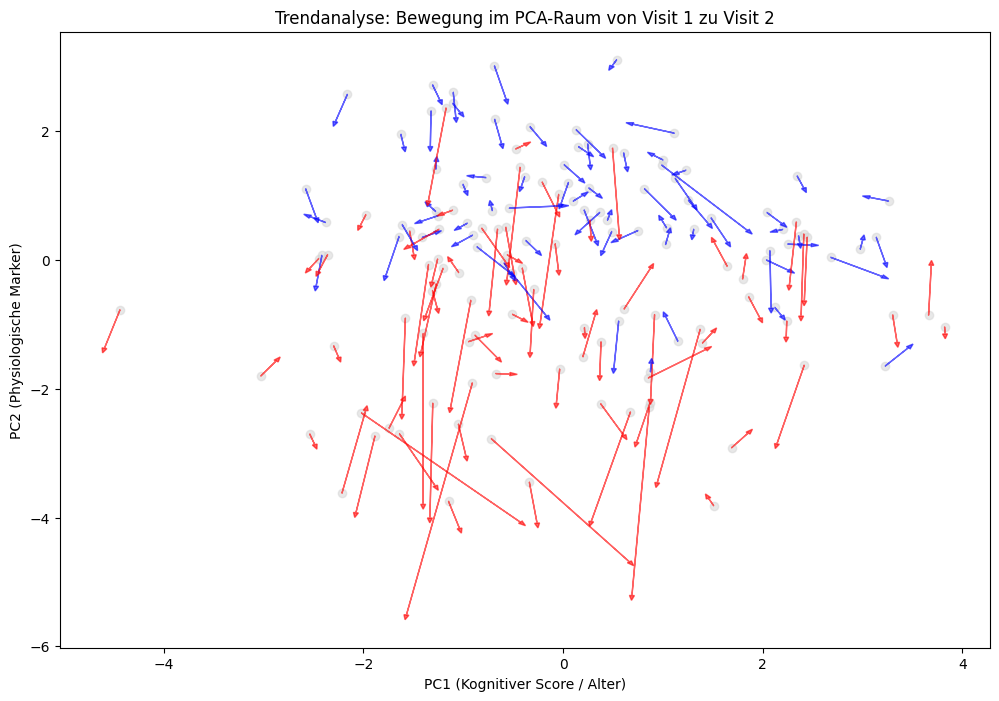

In [34]:
df_visit_2 = df[df["Visit"] == 2].copy()
common_ids = set(df_visit_1["Subject ID"]).intersection(set(df_visit_2["Subject ID"]))
v1_sub = df_visit_1[df_visit_1["Subject ID"].isin(common_ids)].sort_values("Subject ID")
v2_sub = df_visit_2[df_visit_2["Subject ID"].isin(common_ids)].sort_values("Subject ID")

scaled_v1 = scaler.transform(v1_sub[features_pca])
scaled_v2 = scaler.transform(v2_sub[features_pca])

pca_v1 = pca.transform(scaled_v1)
pca_v2 = pca.transform(scaled_v2)

plt.figure(figsize=(12, 8))
plt.scatter(pca_v1[:, 0], pca_v1[:, 1], c='lightgrey', alpha=0.5, label='Start (Visit 1)')

for i in range(len(pca_v1)):
    color = 'blue' if v2_sub.iloc[i]['Group'] == 'Nondemented' else 'red'
    plt.arrow(pca_v1[i, 0], pca_v1[i, 1], 
            pca_v2[i, 0] - pca_v1[i, 0], 
            pca_v2[i, 1] - pca_v1[i, 1], 
            head_width=0.05, color=color, alpha=0.6)
    

plt.title('Trendanalyse: Bewegung im PCA-Raum von Visit 1 zu Visit 2')
plt.xlabel('PC1 (Kognitiver Score / Alter)')
plt.ylabel('PC2 (Physiologische Marker)')
plt.show()


#### "Converted"-Vorhersage (Das Frühwarnsystem)